<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Weather_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install requests pandas matplotlib scikit-learn

In [2]:
import requests
import pandas as pd
from datetime import datetime

API_KEY = "bd5e378503939ddaee76f12ad7a97608"  # Replace with your key
CITY = "Baku"
URL = f"http://api.openweathermap.org/data/2.5/weather?q={CITY}&appid={API_KEY}&units=metric"

response = requests.get(URL)
data = response.json()

# Extract useful info
weather_info = {
    "city": CITY,
    "time": datetime.utcfromtimestamp(data["dt"]),
    "temperature": data["main"]["temp"],
    "humidity": data["main"]["humidity"],
    "pressure": data["main"]["pressure"],
    "weather": data["weather"][0]["description"]
}

df = pd.DataFrame([weather_info])
df


,city,time,temperature,humidity,pressure,weather
0,Baku,2025-08-14 11:50:39,30.03,42,1017,clear sky


In [3]:
import numpy as np

# Simulate last 50 hours of temperature
dates = pd.date_range(end=datetime.now(), periods=50, freq="H")
temps = df["temperature"].iloc[0] + np.random.randn(50)  # random variation

historical_df = pd.DataFrame({"time": dates, "temperature": temps})
historical_df.head()


/tmp/ipython-input-2977119019.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(end=datetime.now(), periods=50, freq="H")


,time,temperature
0,2025-08-12 10:50:48.073693,30.059727
1,2025-08-12 11:50:48.073693,30.724235
2,2025-08-12 12:50:48.073693,31.667759
3,2025-08-12 13:50:48.073693,29.637271
4,2025-08-12 14:50:48.073693,29.533067


In [4]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare features (hours since start)
historical_df["hour_index"] = np.arange(len(historical_df))
X = historical_df[["hour_index"]]
y = historical_df["temperature"]

model = LinearRegression()
model.fit(X, y)

# Predict next 12 hours
future_hours = np.arange(len(historical_df), len(historical_df) + 12).reshape(-1, 1)
predictions = model.predict(future_hours)

forecast_df = pd.DataFrame({
    "time": pd.date_range(start=historical_df["time"].iloc[-1] + pd.Timedelta(hours=1), periods=12, freq="H"),
    "predicted_temp": predictions
})
forecast_df


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipython-input-2907466898.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "time": pd.date_range(start=historical_df["time"].iloc[-1] + pd.Timedelta(hours=1), periods=12, freq="H"),


,time,predicted_temp
0,2025-08-14 12:50:48.073693,29.461071
1,2025-08-14 13:50:48.073693,29.438449
2,2025-08-14 14:50:48.073693,29.415827
3,2025-08-14 15:50:48.073693,29.393205
4,2025-08-14 16:50:48.073693,29.370583
5,2025-08-14 17:50:48.073693,29.347961
6,2025-08-14 18:50:48.073693,29.325339
7,2025-08-14 19:50:48.073693,29.302717
8,2025-08-14 20:50:48.073693,29.280095
9,2025-08-14 21:50:48.073693,29.257473


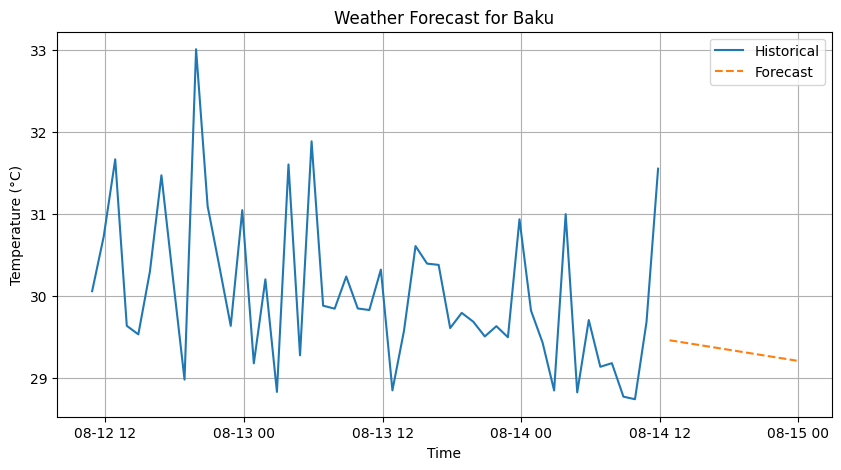

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(historical_df["time"], historical_df["temperature"], label="Historical")
plt.plot(forecast_df["time"], forecast_df["predicted_temp"], label="Forecast", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(f"Weather Forecast for {CITY}")
plt.legend()
plt.grid(True)
plt.show()
